In [1]:
import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.model import Unet
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate
from torch import optim
from sda.mcs import KolmogorovFlow

device = 'cuda'

In [2]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


In [3]:
model_psd_end_training =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/best_model.pth')
model_psd_end_training.load_state_dict(checkpoint)
model_psd_end_training.eval()

model_linear =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/best_model.pth')
model_linear.load_state_dict(checkpoint)
model_linear.eval()

model_psd_plus = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_223/best_model.pth')
model_psd_plus.load_state_dict(checkpoint)
model_psd_plus.eval()

DiffusionModel(
  (unet): Unet(
    (init_conv): Conv2d(4, 42, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), padding_mode=circular)
    (time_mlp): Sequential(
      (0): SinusoidalPositionEmbeddings()
      (1): Linear(in_features=64, out_features=256, bias=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (downs): ModuleList(
      (0): ModuleList(
        (0): ConvNextBlock(
          (mlp): Sequential(
            (0): GELU(approximate='none')
            (1): Linear(in_features=256, out_features=42, bias=True)
          )
          (ds_conv): Conv2d(42, 42, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=42, padding_mode=circular)
          (net): Sequential(
            (0): GroupNorm(1, 42, eps=1e-05, affine=True)
            (1): Conv2d(42, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
            (2): GELU(approximate='none')
            (3): GroupNorm(1, 64, eps=1e

In [4]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [5]:
model = model_psd_plus

In [6]:
statistics_eval_mode = {}

targets = []
conditions = []
estimates = []
estimates_clean = []

with torch.no_grad():
    for batch_idx, sample in enumerate(traj_loader):
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]

        estimate, _ = compute_estimate(model, 0, conditioning_frame, target_frame)
        pred = model(conditioning_frame, return_x0_estimate = False, input_type='ancestor', return_denoiser_inputs=False)

        pred2_estimate = model(estimate, return_x0_estimate = False, input_type='ancestor', return_denoiser_inputs=False)
        pred2_pred = model(pred, return_x0_estimate = False, input_type='ancestor', return_denoiser_inputs=False)
        
        print(torch.mean((pred-target_frame)**2))
        print(torch.mean((estimate-target_frame)**2))
        print(torch.mean((pred2_pred-data[:,2])**2))
        print(torch.mean((pred2_estimate-data[:,2])**2))
        if batch_idx == 0: 
            break

NameError: name 'compute_estimate' is not defined

### Training a correction Unet

In [6]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [3, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [7]:
def compute_estimate(model, k, cond, gt):
    #dNoisy = torch.randn_like(gt).to('cuda')

    interm_estimates = []
    
    #dNoisy = torch.randn_like(gt).to('cuda')
    dNoisy = model.sqrtAlphasCumprod[k] * gt + model.sqrtOneMinusAlphasCumprod[k] * torch.randn_like(gt).to('cuda')

    for i in reversed(range(0, k+1, 1)):

        t = i * torch.ones(dNoisy.shape[0]).to('cuda').long()
        dNoiseCond = torch.concat((cond, dNoisy), dim=1)

        predictedNoiseCond = model.unet(dNoiseCond, t)

        # use model (noise predictor) to predict mean
        modelMean = model.sqrtRecipAlphas[t] * (dNoiseCond - model.betas[t] * predictedNoiseCond / model.sqrtOneMinusAlphasCumprod[t])
        dNoisy = modelMean[:, cond.shape[1]:]

        if i != 0:
        
            dNoisy = dNoisy + model.sqrtPosteriorVariance[t] * torch.randn_like(dNoisy)

        estimate = (dNoiseCond[:, cond.shape[1]:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, cond.shape[1]:])/model.sqrtAlphasCumprod[t]

        interm_estimates.append(estimate)

    return dNoisy, interm_estimates

In [8]:
import copy
from src.model import Unet
correcting_unet = Unet(
        dim=64,
        channels= 2,
        dim_mults=(1,1,1),
        use_convnext=True,
        convnext_mult=1,
        padding_mode='circular',
        with_time_emb=False 
    )

#nn.init.zeros_(correcting_unet.final_conv)

for name, param in correcting_unet.named_parameters():
    if "final_conv.1" in name:
        with torch.no_grad():
            param.mul_(0)

correcting_unet.to('cuda')

Unet(
  (init_conv): Conv2d(2, 42, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), padding_mode=circular)
  (downs): ModuleList(
    (0): ModuleList(
      (0): ConvNextBlock(
        (ds_conv): Conv2d(42, 42, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=42, padding_mode=circular)
        (net): Sequential(
          (0): GroupNorm(1, 42, eps=1e-05, affine=True)
          (1): Conv2d(42, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
          (2): GELU(approximate='none')
          (3): GroupNorm(1, 64, eps=1e-05, affine=True)
          (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
        )
        (res_conv): Conv2d(42, 64, kernel_size=(1, 1), stride=(1, 1), padding_mode=circular)
      )
      (1): ConvNextBlock(
        (ds_conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=64, padding_mode=circular)
        (net): Sequential(
          (0): GroupNorm(1, 64, 

In [53]:
import copy

model_psd_plus = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",
        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/best_model.pth')
model_psd_plus.load_state_dict(checkpoint)
model_psd_plus.eval()

model = model_psd_plus
model_2nd_step = copy.deepcopy(model)

correcting_unet.to('cuda')
model.to('cuda')

DiffusionModel(
  (unet): Unet(
    (init_conv): Conv2d(4, 42, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), padding_mode=circular)
    (time_mlp): Sequential(
      (0): SinusoidalPositionEmbeddings()
      (1): Linear(in_features=64, out_features=256, bias=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (downs): ModuleList(
      (0): ModuleList(
        (0): ConvNextBlock(
          (mlp): Sequential(
            (0): GELU(approximate='none')
            (1): Linear(in_features=256, out_features=42, bias=True)
          )
          (ds_conv): Conv2d(42, 42, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=42, padding_mode=circular)
          (net): Sequential(
            (0): GroupNorm(1, 42, eps=1e-05, affine=True)
            (1): Conv2d(42, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
            (2): GELU(approximate='none')
            (3): GroupNorm(1, 64, eps=1e

In [ ]:
epoch_sampling_frequency = 20
best_val_loss = float('inf')
best_traj_time = 0
best_traj_error = 100000000
optimizer = optim.Adam(model.parameters(), lr=0.00001)
device = torch.device('cuda')
criterion = torch.nn.MSELoss()

correcting_unet.to(device)
model.to(device)
model_2nd_step.to(device)
#for param in model.parameters():
#    param.requires_grad = False

for epoch in range(1000):
    # (Training and validation loops remain unchanged)
    model.train()
    model_2nd_step.train()
    running_train_loss = 0.0
    for batch_idx, sample in enumerate(train_loader):
        data = sample["data"].to(device)
        optimizer.zero_grad()
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]
        target_frame_0 = data[:, 1]
        target_frame_1 = data[:, 2]
        
        #with torch.no_grad():
        estimate_frame_0, _ = compute_estimate(model, 5, conditioning_frame_0, target_frame_0)

        #corrected_estimate_frame_0 = correcting_unet(estimate_frame_0, time=None) + estimate_frame_0
    
        noise, predicted_noise = model(estimate_frame_0, target_frame_1, return_x0_estimate=False, upper_limit_timesteps_training=5)
        loss += criterion(predicted_noise, noise)

        running_train_loss += loss.item()
        loss.backward()
        optimizer.step()
    avg_train_loss = running_train_loss / (batch_idx + 1)

    print(f"Training loss : {avg_train_loss:.8f}")
    
    if val_loader is None:
        avg_val_loss = 0.0
    else:
        # (Training and validation loops remain unchanged)
        model.train()
        running_val_loss = 0.0
        for batch_idx, sample in enumerate(val_loader):
            data = sample["data"].to(device)
            optimizer.zero_grad()
            loss = torch.Tensor([0]).to(device)

            conditioning_frame_0 = data[:, 0]
            target_frame_0 = data[:, 1]
            target_frame_1 = data[:, 2]

            with torch.no_grad():
                
                estimate_frame_0, _ = compute_estimate(model, 0, conditioning_frame_0, target_frame_0)

                #corrected_estimate_frame_0 = correcting_unet(estimate_frame_0, time=None) + estimate_frame_0
        
                noise, predicted_noise = model(estimate_frame_0, target_frame_1, return_x0_estimate=False, upper_limit_timesteps_training=5)

                loss += criterion(predicted_noise, noise)

            running_val_loss += loss.item()
            optimizer.step()
        avg_val_loss = running_val_loss / (batch_idx + 1)

    # --- Base Logging Logic ---
    log_dict = {
        "epoch": epoch + 1,
        "training_loss": avg_train_loss,
        "validation_loss": avg_val_loss,
        "best_traj_time": best_traj_time,
        "best_traj_error": best_traj_time
    }

    print(f"Epoch [{epoch+1}/1000], Training Loss: {avg_train_loss:.8f}, Validation Loss: {avg_val_loss:.8f}")


### 4 steps ?

In [46]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [5, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 100,
        "limit_trajectories_val": 1,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

epoch_sampling_frequency = 20
best_val_loss = float('inf')
best_traj_time = 0
best_traj_error = 100000000
optimizer = optim.Adam(model.parameters(), lr=0.000001)
device = torch.device('cuda')
criterion = torch.nn.MSELoss()

correcting_unet.to(device)
model.to(device)
model_2nd_step.to(device)
#for param in model.parameters():
#    param.requires_grad = False

for epoch in range(1000):
    # (Training and validation loops remain unchanged)
    model.train()
    model_2nd_step.train()
    running_train_loss = 0.0
    for batch_idx, sample in enumerate(train_loader):
        data = sample["data"].to(device)
        optimizer.zero_grad()
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]
        target_frame_0 = data[:, 1]
        target_frame_1 = data[:, 2]
        
        noise, predicted_noise = model(data[:,0], data[:, 1], return_x0_estimate=False, upper_limit_timesteps_training=1)
        loss += criterion(predicted_noise, noise)

        running_train_loss += loss.item()
        loss.backward()
        optimizer.step()
    avg_train_loss = running_train_loss / (batch_idx + 1)

    print(f"Training loss : {avg_train_loss:.8f}")

aaaa 819
aaaa 102
aaaa 102
Training loss : 0.00246613
Training loss : 0.00245091
Training loss : 0.00244736


KeyboardInterrupt: 

In [ ]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [5, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 100,
        "limit_trajectories_val": 1,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

epoch_sampling_frequency = 20
best_val_loss = float('inf')
best_traj_time = 0
best_traj_error = 100000000
optimizer = optim.Adam(model.parameters(), lr=0.000001)
device = torch.device('cuda')
criterion = torch.nn.MSELoss()

model.to(device)
#for param in model.parameters():
#    param.requires_grad = False

for epoch in range(1000):
    # (Training and validation loops remain unchanged)
    model.train()
    running_train_loss = 0.0
    for batch_idx, sample in enumerate(train_loader):
        data = sample["data"].to(device)
        optimizer.zero_grad()
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]
        target_frame_0 = data[:, 1]
        target_frame_1 = data[:, 2]
        
        
        estimate_frame_0, _ = compute_estimate(model, 0, data[:, 0], data[:, 1])
        estimate_frame_1, _ = compute_estimate(model, 0, estimate_frame_0, data[:, 2])
        #estimate_frame_2, _ = compute_estimate(model, 0, estimate_frame_1, data[:, 3])

    
        #noise, predicted_noise = model(data[:,0], data[:, 1], return_x0_estimate=False, upper_limit_timesteps_training=1)
        noise, predicted_noise = model(estimate_frame_0, data[:, 2], return_x0_estimate=False, upper_limit_timesteps_training=1)
        loss += criterion(predicted_noise, noise)
        noise, predicted_noise = model(estimate_frame_1, data[:, 3], return_x0_estimate=False, upper_limit_timesteps_training=1)
        loss += criterion(predicted_noise, noise)
        #noise, predicted_noise = model(estimate_frame_2, data[:, 4], return_x0_estimate=False, upper_limit_timesteps_training=1)
        #loss += criterion(predicted_noise, noise)

        running_train_loss += loss.item()
        loss.backward()
        optimizer.step()
    avg_train_loss = running_train_loss / (batch_idx + 1)

    print(f"Training loss : {avg_train_loss:.8f}")

In [56]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [5, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 100,
        "limit_trajectories_val": 1,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

epoch_sampling_frequency = 20
best_val_loss = float('inf')
best_traj_time = 0
best_traj_error = 100000000
optimizer = optim.Adam(model.parameters(), lr=0.000001)
device = torch.device('cuda')
criterion = torch.nn.MSELoss()

model.to(device)
#for param in model.parameters():
#    param.requires_grad = False

for epoch in range(1000):
    # (Training and validation loops remain unchanged)
    model.train()
    running_train_loss = 0.0
    for batch_idx, sample in enumerate(train_loader):
        data = sample["data"].to(device)
        optimizer.zero_grad()
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]
        target_frame_0 = data[:, 1]
        target_frame_1 = data[:, 2]
        target_frame_2 = data[:, 3]


        estimate_frame_0, _ = compute_estimate(model, 2, data[:, 0], data[:, 1])
        estimate_frame_1, _ = compute_estimate(model, 2, estimate_frame_0, data[:, 2])
        estimate_frame_2, _ = compute_estimate(model, 2, estimate_frame_1, data[:, 3])

    
        #noise, predicted_noise = model(data[:,0], data[:, 1], return_x0_estimate=False, upper_limit_timesteps_training=1)
        loss += criterion(estimate_frame_0, target_frame_0)
        loss += criterion(estimate_frame_1, target_frame_1)
        loss += criterion(estimate_frame_2, target_frame_2)
        #noise, predicted_noise = model(estimate_frame_2, data[:, 4], return_x0_estimate=False, upper_limit_timesteps_training=1)
        #loss += criterion(predicted_noise, noise)

        running_train_loss += loss.item()
        loss.backward()
        optimizer.step()
    avg_train_loss = running_train_loss / (batch_idx + 1)

    print(f"Training loss : {avg_train_loss:.8f}")

In [37]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [5, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 100,
        "limit_trajectories_val": 1,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

epoch_sampling_frequency = 20
best_val_loss = float('inf')
best_traj_time = 0
best_traj_error = 100000000
optimizer = optim.Adam(model.parameters(), lr=0.000001)
device = torch.device('cuda')
criterion = torch.nn.MSELoss()

model.to(device)
#for param in model.parameters():
#    param.requires_grad = False

for epoch in range(1000):
    # (Training and validation loops remain unchanged)
    model.train()
    running_train_loss = 0.0
    for batch_idx, sample in enumerate(train_loader):
        data = sample["data"].to(device)
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]
        target_frame_0 = data[:, 1]
        target_frame_1 = data[:, 2]
        
        
        estimate_frame_0, _ = compute_estimate(model, 0, data[:, 0], data[:, 1])
        estimate_frame_1, _ = compute_estimate(model, 0, estimate_frame_0, data[:, 2])
        #estimate_frame_2, _ = compute_estimate(model, 0, estimate_frame_1, data[:, 3])

    
        #noise, predicted_noise = model(data[:,0], data[:, 1], return_x0_estimate=False, upper_limit_timesteps_training=1)
        noise, predicted_noise = model(estimate_frame_0, data[:, 2], return_x0_estimate=False, upper_limit_timesteps_training=1)
        loss += criterion(predicted_noise, noise)
        noise, predicted_noise = model(estimate_frame_1, data[:, 3], return_x0_estimate=False, upper_limit_timesteps_training=1)
        loss += criterion(predicted_noise, noise)
        #noise, predicted_noise = model(estimate_frame_2, data[:, 4], return_x0_estimate=False, upper_limit_timesteps_training=1)
        #loss += criterion(predicted_noise, noise)

        running_train_loss += loss.item()
    avg_train_loss = running_train_loss / (batch_idx + 1)

    print(f"Training loss : {avg_train_loss:.8f}")

aaaa 819
aaaa 102
aaaa 102
Training loss : 0.01199283


KeyboardInterrupt: 

In [52]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [5, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 10,
        "limit_trajectories_val": 5,
        "batch_size": 512
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

epoch_sampling_frequency = 20
best_val_loss = float('inf')
best_traj_time = 0
best_traj_error = 100000000
device = torch.device('cuda')
criterion = torch.nn.MSELoss()

model.to(device)
#for param in model.parameters():
#    param.requires_grad = False

for epoch in range(1000):
    # (Training and validation loops remain unchanged)
    model.train()
    model_2nd_step.train()
    running_train_loss = 0.0
    for batch_idx, sample in enumerate(val_loader):
        data = sample["data"].to(device)
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]
        target_frame_0 = data[:, 1]
        target_frame_1 = data[:, 2]
        with torch.no_grad():
            #model.eval()
            #estimate_frame_0 = model(conditioning_frame_0)
            estimate_frame_0, _ = compute_estimate(model, 5, data[:, 0], data[:, 1])
            estimate_frame_1, _ = compute_estimate(model, 5, estimate_frame_0, data[:, 2])
            estimate_frame_2, _ = compute_estimate(model, 5, estimate_frame_1, data[:, 3])

            loss += criterion(estimate_frame_2, target_frame_2)
        #noise, predicted_noise = model(estimate_frame_2, data[:, 4], return_x0_estimate=False, upper_limit_timesteps_training=1)
        #loss += criterion(predicted_noise, noise)

        running_train_loss += loss.item()
        #loss.backward()
        #optimizer.step()
    avg_train_loss = running_train_loss / (batch_idx + 1)

    print(f"Training loss : {avg_train_loss:.8f}")

aaaa 819
aaaa 102
aaaa 102
Training loss : 0.00000332
Training loss : 0.00000332
Training loss : 0.00000332


KeyboardInterrupt: 

In [55]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [5, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 10,
        "limit_trajectories_val": 5,
        "batch_size": 512
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

epoch_sampling_frequency = 20
best_val_loss = float('inf')
best_traj_time = 0
best_traj_error = 100000000
device = torch.device('cuda')
criterion = torch.nn.MSELoss()

model.to(device)
#for param in model.parameters():
#    param.requires_grad = False

for epoch in range(1000):
    # (Training and validation loops remain unchanged)
    model.train()
    model_2nd_step.train()
    running_train_loss = 0.0
    for batch_idx, sample in enumerate(val_loader):
        data = sample["data"].to(device)
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]
        target_frame_0 = data[:, 1]
        target_frame_1 = data[:, 2]
        target_frame_2 = data[:, 3]
        with torch.no_grad():
            model.eval()
            #estimate_frame_0 = model(conditioning_frame_0)
            estimate_frame_0 = model(data[:, 0])
            estimate_frame_1 = model(estimate_frame_0)
            estimate_frame_2 = model(estimate_frame_1)

            #model.train()
            #noise, predicted_noise = model(data[:,0], data[:, 1], return_x0_estimate=False, upper_limit_timesteps_training=1)
            #noise, predicted_noise = model(estimate_frame_0, data[:, 2], return_x0_estimate=False, upper_limit_timesteps_training=1)
            loss += criterion(estimate_frame_2, target_frame_2)
            #noise, predicted_noise = model(estimate_frame_1, data[:, 3], return_x0_estimate=False, upper_limit_timesteps_training=1)
            #loss += criterion(predicted_noise, noise)
        #noise, predicted_noise = model(estimate_frame_2, data[:, 4], return_x0_estimate=False, upper_limit_timesteps_training=1)
        #loss += criterion(predicted_noise, noise)

        running_train_loss += loss.item()
        #loss.backward()
        #optimizer.step()
    avg_train_loss = running_train_loss / (batch_idx + 1)

    print(f"Training loss : {avg_train_loss:.8f}")

aaaa 819
aaaa 102
aaaa 102
Training loss : 0.00000355


KeyboardInterrupt: 

In [19]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [5, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 10,
        "limit_trajectories_val": 1,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

epoch_sampling_frequency = 20
best_val_loss = float('inf')
best_traj_time = 0
best_traj_error = 100000000
device = torch.device('cuda')
criterion = torch.nn.MSELoss()

model.to(device)
#for param in model.parameters():
#    param.requires_grad = False

for epoch in range(1000):
    # (Training and validation loops remain unchanged)
    model.eval()
    running_train_loss = 0.0
    for batch_idx, sample in enumerate(train_loader):
        data = sample["data"].to(device)
        optimizer.zero_grad()
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]
        target_frame_0 = data[:, 1]
        target_frame_1 = data[:, 2]
        
        with torch.no_grad():
            estimate_frame_0  = model(conditioning_frame_0)
            estimate_frame_1 = model(estimate_frame_0)
        #estimate_frame_2, _ = compute_estimate(model, 0, estimate_frame_1, data[:, 3])
        loss = criterion(estimate_frame_1, target_frame_1)

        running_train_loss += loss.item()
        #loss.backward()
        #optimizer.step()
    avg_train_loss = running_train_loss / (batch_idx + 1)

    print(f"Training loss : {avg_train_loss:.8f}")

aaaa 819
aaaa 102
aaaa 102
Training loss : 0.00011378


KeyboardInterrupt: 

In [ ]:
if val_loader is None:
        avg_val_loss = 0.0
else:
    # (Training and validation loops remain unchanged)
    model.train()
    running_val_loss_0 = 0.0
    running_val_loss_1 = 0.0
    running_target_loss_0 = 0.0
    running_target_loss_1 = 0.0
    for batch_idx, sample in enumerate(val_loader):
        data = sample["data"].to(device)
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]
        target_frame_0 = data[:, 1]
        target_frame_1 = data[:, 2]

        with torch.no_grad():

            #noise, predicted_noise, estimates = model(conditioning_frame_0, target_frame_0, return_x0_estimate=True, limit_timesteps_training=1)
            estimate_frame_0, _ = compute_estimate(model, 0, conditioning_frame_0, target_frame_0)
            
            corrected_estimate_frame_0 = estimate_frame_0
            noise, predicted_noise, estimates = model(corrected_estimate_frame_0, target_frame_1, return_x0_estimate=True, limit_timesteps_training=1)
            running_val_loss_0 += torch.mean((noise - predicted_noise)**2)

            running_target_loss_0 += torch.mean((estimate_frame_0 - target_frame_0)**2)
            corrected_estimate_frame_0 = correcting_unet(estimate_frame_0, time=None) + estimate_frame_0

            running_target_loss_1 += torch.mean((corrected_estimate_frame_0 - target_frame_0)**2)

            noise, predicted_noise, estimates = model_2nd_step(corrected_estimate_frame_0, target_frame_1, return_x0_estimate=True)
            running_val_loss_1 += torch.mean((noise - predicted_noise)**2)

    avg_val_loss_0 = running_val_loss_0 / (batch_idx + 1)
    print(avg_val_loss_0)
    avg_val_loss_1 = running_val_loss_1 / (batch_idx + 1)
    print(avg_val_loss_1)
    avg_target_loss_0 = running_target_loss_0 / (batch_idx + 1)
    print(avg_target_loss_0)
    avg_target_loss_1 = running_target_loss_1 / (batch_idx + 1)
    print(avg_target_loss_1)

    #print(avg_val_loss)

In [92]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [5, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 100,
        "limit_trajectories_val": 102,
        "batch_size": 512
    }

model.eval()
model_2nd_step.eval()
running_val_pred_0 = 0.0
running_val_pred_1 = 0.0
running_val_pred_corrected_0 = 0.0
running_val_pred_corrected_1 = 0.0
for batch_idx, sample in enumerate(train_loader):
    data = sample["data"].to(device)
    loss = torch.Tensor([0]).to(device)

    conditioning_frame_0 = data[:, 0]

    with torch.no_grad():

        pred_1 = data[:, 0]
        pred_1_corrected = data[:, 0]

        for t in range(20):

            print(t)
            model.train()
            noise, predicted_noise, estimates = model(pred_1, data[:, t+1], return_x0_estimate=True, upper_limit_timesteps_training=1)
            print(torch.mean((noise-predicted_noise)**2))
            model.eval()
            pred_1 = model(pred_1)
            model_2nd_step.train()
            noise, predicted_noise, estimates = model_2nd_step(pred_1_corrected, data[:, t+1], return_x0_estimate=True, upper_limit_timesteps_training=1)
            print(torch.mean((noise-predicted_noise)**2))
            model_2nd_step.eval()
            pred_1_corrected = model_2nd_step(pred_1_corrected)
            #pred_1_corrected = model(pred_1_corrected, correcting_unet=correcting_unet)

            print(torch.mean((pred_1 - data[:,t+1])**2))
            print(torch.mean((pred_1_corrected - data[:,t+1])**2))

    break

#print(avg_val_loss)

0
tensor(0.0025, device='cuda:0')
tensor(0.0027, device='cuda:0')
tensor(1.2250e-06, device='cuda:0')
tensor(1.2699e-06, device='cuda:0')
1
tensor(0.0050, device='cuda:0')
tensor(0.0057, device='cuda:0')
tensor(2.4440e-06, device='cuda:0')
tensor(2.7739e-06, device='cuda:0')
2
tensor(0.0077, device='cuda:0')
tensor(0.0093, device='cuda:0')
tensor(3.8436e-06, device='cuda:0')
tensor(4.6174e-06, device='cuda:0')
3
tensor(0.0109, device='cuda:0')
tensor(0.0141, device='cuda:0')
tensor(5.4398e-06, device='cuda:0')
tensor(7.0927e-06, device='cuda:0')
4


IndexError: index 5 is out of bounds for dimension 1 with size 5

In [ ]:
if val_loader is None:
        avg_val_loss = 0.0
else:
    # (Training and validation loops remain unchanged)
    model.eval()
    model_2nd_step.eval()
    running_val_pred_0 = 0.0
    running_val_pred_1 = 0.0
    running_val_pred_corrected_0 = 0.0
    running_val_pred_corrected_1 = 0.0
    for batch_idx, sample in enumerate(traj_loader):
        data = sample["data"].to(device)
        loss = torch.Tensor([0]).to(device)

        conditioning_frame_0 = data[:, 0]

        with torch.no_grad():

            pred_1 = data[:, 0]
            pred_1_corrected = data[:, 0]

            for t in range(20):

                pred_1, _ = compute_estimate(model, 0, pred_1, data[:, t+1])
                pred_1_corrected = model(pred_1_corrected)
                #pred_1_corrected = model(pred_1_corrected, correcting_unet=correcting_unet)

                print(torch.mean((pred_1 - data[:,t+1])**2))
                print(torch.mean((pred_1_corrected - data[:,t+1])**2))

        break

    #print(avg_val_loss)

In [85]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [5, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 100,
        "limit_trajectories_val": 102,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [ ]:
# (Training and validation loops remain unchanged)
model.eval()
model_2nd_step.eval()
running_val_loss = 0.0
for batch_idx, sample in enumerate(val_loader):
    data = sample["data"].to(device)
    optimizer.zero_grad()
    loss = torch.Tensor([0]).to(device)

    conditioning_frame_0 = data[:, 0]
    target_frame_0 = data[:, 1]
    target_frame_1 = data[:, 2]

    with torch.no_grad():

        #_, x0_estimates_clean, inputs_clean = model(target_frame_0, data=target_frame, return_x0_estimate = True, input_type='clean', return_denoiser_inputs=True)

        pred_0_TF = model(conditioning_frame_0, return_x0_estimate = False, input_type='ancestor', return_denoiser_inputs=False)
        pred_0_UT = model_2nd_step(conditioning_frame_0, return_x0_estimate = False, input_type='ancestor', return_denoiser_inputs=False)
        pred_1_TF = model(pred_0_TF, return_x0_estimate = False, input_type='ancestor', return_denoiser_inputs=False)
        pred_1_UT = model_2nd_step(pred_0_UT, return_x0_estimate = False, input_type='ancestor', return_denoiser_inputs=False)

        print("Step 0 TF:",torch.mean((pred_0_TF - target_frame_0)**2))
        print("Step 0 UT:",torch.mean((pred_0_UT - target_frame_0)**2))
        print("Step 1 TF:", torch.mean((pred_1_TF - target_frame_1)**2))
        print("Step 1 UT:", torch.mean((pred_1_UT - target_frame_1)**2))

    break

print(avg_val_loss)

In [ ]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

In [ ]:
from src.utils import evaluate_trajectory_mse
longterm_errors = {}

models = {"UT":model, "TF":model_2nd_step}

for name in models:

    model = models[name]
    results_model = evaluate_trajectory_mse(model, traj_loader, device, threshold=0.8)

    longterm_errors[name] = results_model

In [ ]:
from src.utils import  evaluate_trajectory_vorticity
models = {"TF":model, "UT":model_2nd_step}

for name in models:

    model = models[name]
    results_model = evaluate_trajectory_vorticity(model, traj_loader, device, threshold=0.8)

    longterm_errors[name] = results_model

In [ ]:
longterm_errors

In [ ]:
for name in longterm_errors:
    plt.plot(longterm_errors[name]["errors_per_ts"], label=name)
    #print(name, longterm_errors[name]["mean"])
plt.yscale('log')
plt.legend()

In [ ]:
import torch

def run_model(model, x):
    """Wrapper for forward pass."""
    if isinstance(model, DiffusionModel):
        return model(x)
    else:
        return model(x, time=None)

def evaluate_models(models, m_eval, traj_loader, device, rollout_steps=30, with_meta_eval=False):
    """
    Compare:
    - plain model rollouts vs. m_eval rollouts (eval_distances)
    - plain model rollouts vs. model(eval(model)) rollouts (meta_distances)

    Args:
        models (dict): { "name": model } dictionary of models to evaluate
        m_eval (nn.Module): evaluator model
        traj_loader (DataLoader): trajectory loader
        device (torch.device): device to run on
        rollout_steps (int): number of rollout steps

    Returns:
        dict with:
            predictions[name]: list of model rollout tensors
            meta_eval[name]: list of model(eval(model)) rollout tensors
            eval_distances[name]: list of distances vs m_eval
            meta_distances[name]: list of distances vs meta trajectory
    """
    # Put all models in eval mode
    for model in list(models.values()) + [m_eval]:
        model.eval()

    if with_meta_eval :
        meta_eval = {name: [] for name in models}
        meta_distances = {name: [] for name in models}
        meta_preds = {name: [] for name in models}
    
    eval_distances = {name: [] for name in models}

    with torch.no_grad():
        sample = next(iter(traj_loader))

        data = sample["data"].to(device)
        print("Input shape:", data.shape)

        conditioning_frame = data[:, 0]

        # Initialize plain and meta trajectories
        preds = {name: run_model(model, conditioning_frame) for name, model in models.items()}
        predictions = {name: [preds[name]] for name, model in models.items()}
        

        # Store step 0
        for name, model in models.items():    
            pred_eval = run_model(m_eval, conditioning_frame)
            if with_meta_eval:
                meta_preds[name].append(pred_eval)
            eval_distances[name].append(torch.mean((pred_eval - preds[name]) ** 2))

        # Rollout
        for t in range(rollout_steps):
            for name, model in models.items():

                eval_pred_on_model = run_model(m_eval, preds[name])

                if with_meta_eval:
                    model_pred_on_eval = run_model(model, meta_preds[name])
                    meta_preds[name] = eval_pred_on_model
                
                # plain model step
                preds[name] = run_model(model, preds[name])
                predictions[name].append(preds[name])
                
                # distance vs m_eval
                eval_distances[name].append(torch.mean((eval_pred_on_model - preds[name]) ** 2))
                # distance vs meta trajectory
                if with_meta_eval:
                    meta_distances[name].append(torch.mean((model_pred_on_eval - preds[name]) ** 2))

    if with_meta_eval:
        return {
            "predictions": preds,
            "meta_eval": meta_eval,
            "eval_distances": eval_distances,
            "meta_distances": meta_distances,
        }
    return {"predictions": predictions,
            "eval_distances": eval_distances,
            "data": data}


In [ ]:
m_eval_1 = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_12/Model_E2460.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval_1.load_state_dict(checkpoint)

m_eval_1.to(device)


m_eval = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E900.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval.load_state_dict(checkpoint)

m_eval.to(device)

In [93]:
results = evaluate_models({"UT": model, "TF": model_2nd_step}, m_eval, train_loader, device, rollout_steps=5)

Input shape: torch.Size([64, 5, 2, 64, 64])


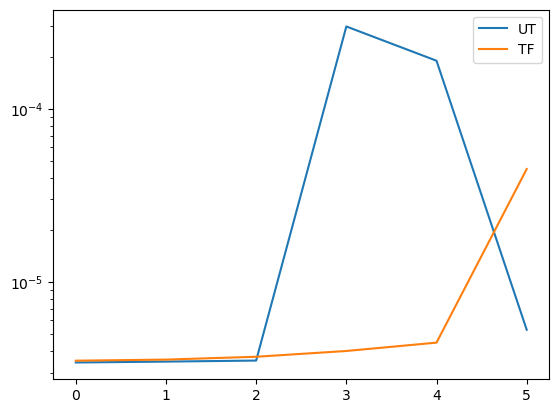

In [94]:
for i, k in enumerate(results["eval_distances"]):
    plt.plot(torch.Tensor(results["eval_distances"][k][:10]), label=k)

plt.yscale('log')

plt.legend()